In [1]:
import scanpy as sc
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=9, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_annotation_with_rbd.h5ad')

In [3]:
adata_OL = adata[adata.obs.cell_class == 'Oligodendrocytes']

In [4]:
sc.tl.pca(adata_OL, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_OL, n_neighbors=20, n_pcs=30)  # tune n_pcs by variance ratio if you like
sc.tl.umap(adata_OL, min_dist=0.3, spread=1.0)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


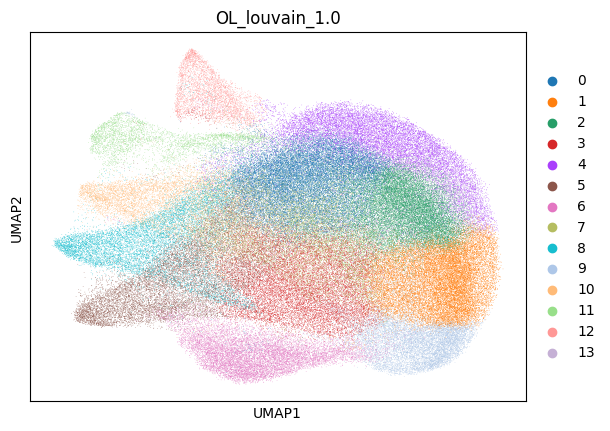

In [7]:
for res in [1.0]:
    sc.tl.louvain(adata_OL, resolution=res, key_added=f"OL_louvain_{res}")
    sc.pl.umap(adata_OL, color = 'OL_louvain_'+str(res))

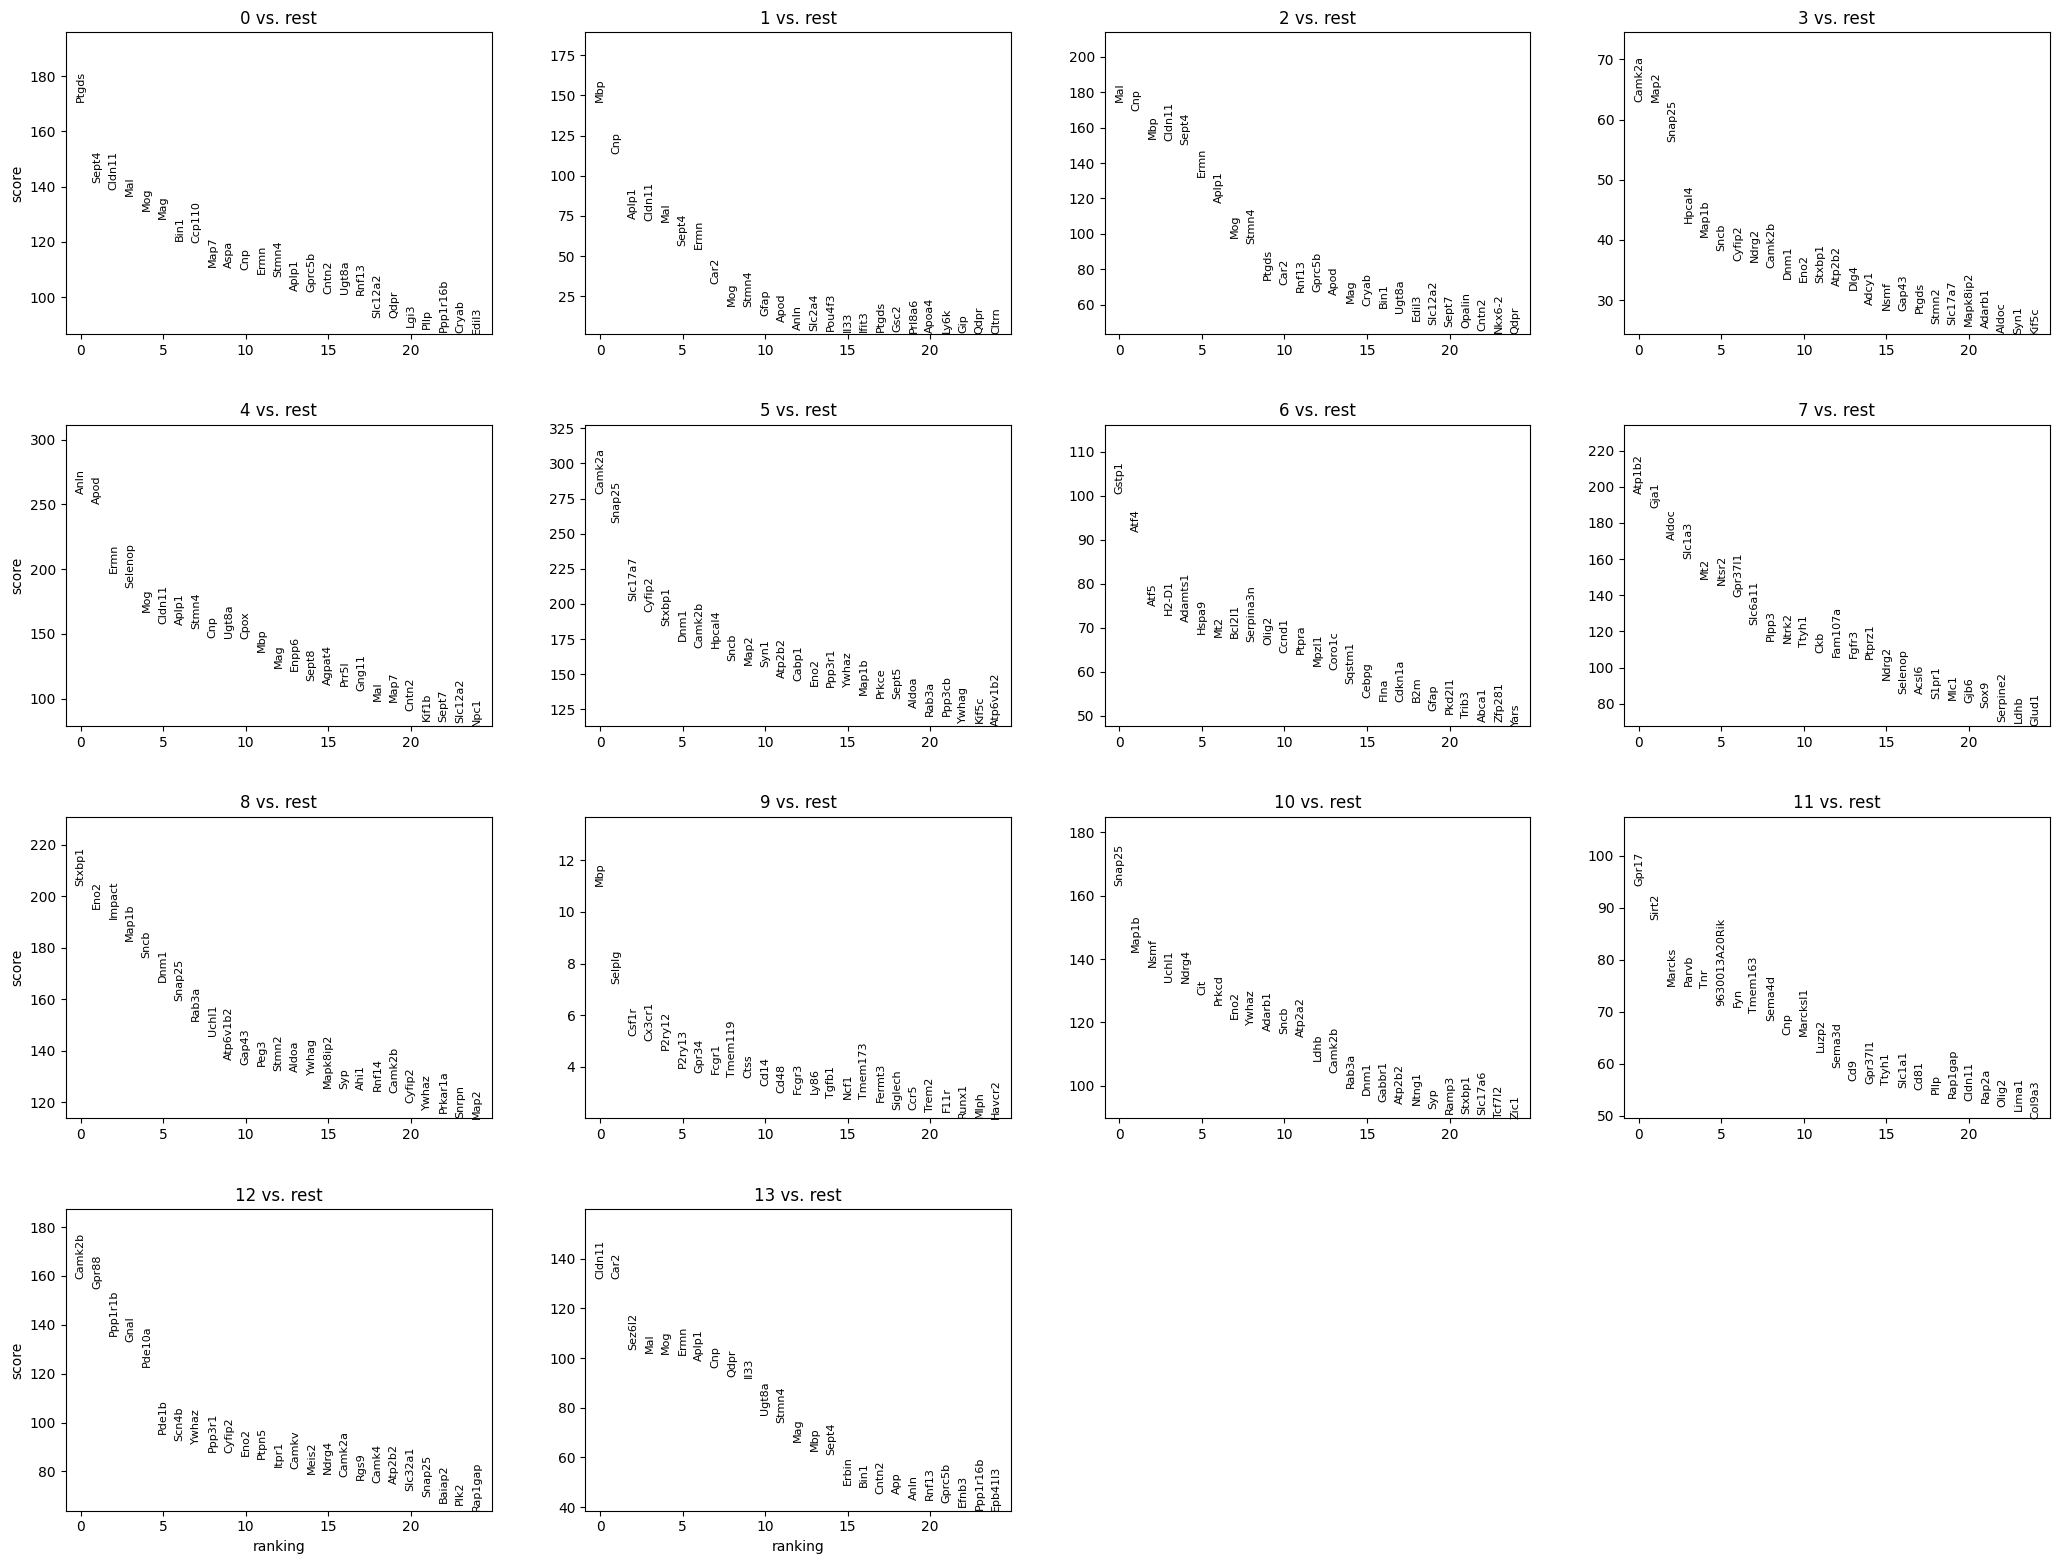

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Ptgds,170.674759,1.808384,0.0,0.0
1,0,Sept4,141.177124,0.987259,0.0,0.0
2,0,Cldn11,138.692184,1.130507,0.0,0.0
3,0,Mal,136.773010,1.185930,0.0,0.0
4,0,Mog,131.341568,1.477007,0.0,0.0


In [8]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(adata_OL, groupby="OL_louvain_1.0", method="t-test")
sc.pl.rank_genes_groups(adata_OL, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(adata_OL, group=None)
markers.head()

In [9]:
import pandas as pd

In [10]:
marker_genes = pd.DataFrame({
    group: adata_OL.uns['rank_genes_groups']['names'][group][:10]
    for group in adata_OL.uns['rank_genes_groups']['names'].dtype.names
})
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

0
Ptgds Sept4 Cldn11 Mal Mog Mag Bin1 Ccp110 Map7 Aspa
 
1
Mbp Cnp Aplp1 Cldn11 Mal Sept4 Ermn Car2 Mog Stmn4
 
2
Mal Cnp Mbp Cldn11 Sept4 Ermn Aplp1 Mog Stmn4 Ptgds
 
3
Camk2a Map2 Snap25 Hpcal4 Map1b Sncb Cyfip2 Ndrg2 Camk2b Dnm1
 
4
Anln Apod Ermn Selenop Mog Cldn11 Aplp1 Stmn4 Cnp Ugt8a
 
5
Camk2a Snap25 Slc17a7 Cyfip2 Stxbp1 Dnm1 Camk2b Hpcal4 Sncb Map2
 
6
Gstp1 Atf4 Atf5 H2-D1 Adamts1 Hspa9 Mt2 Bcl2l1 Serpina3n Olig2
 
7
Atp1b2 Gja1 Aldoc Slc1a3 Mt2 Ntsr2 Gpr37l1 Slc6a11 Plpp3 Ntrk2
 
8
Stxbp1 Eno2 Impact Map1b Sncb Dnm1 Snap25 Rab3a Uchl1 Atp6v1b2
 
9
Mbp Selplg Csf1r Cx3cr1 P2ry12 P2ry13 Gpr34 Fcgr1 Tmem119 Ctss
 
10
Snap25 Map1b Nsmf Uchl1 Ndrg4 Cit Prkcd Eno2 Ywhaz Adarb1
 
11
Gpr17 Sirt2 Marcks Parvb Tnr 9630013A20Rik Fyn Tmem163 Sema4d Cnp
 
12
Camk2b Gpr88 Ppp1r1b Gnal Pde10a Pde1b Scn4b Ywhaz Ppp3r1 Cyfip2
 
13
Cldn11 Car2 Sez6l2 Mal Mog Ermn Aplp1 Cnp Qdpr Il33
 


In [11]:
marker_genes = pd.DataFrame({
    group: adata_OL.uns['rank_genes_groups']['names'][group][:4]
    for group in adata_OL.uns['rank_genes_groups']['names'].dtype.names
})


In [12]:
cellclass_markers_top4 = {}
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')
    cellclass_markers_top4[col] = genes

0
Ptgds Sept4 Cldn11 Mal
 
1
Mbp Cnp Aplp1 Cldn11
 
2
Mal Cnp Mbp Cldn11
 
3
Camk2a Map2 Snap25 Hpcal4
 
4
Anln Apod Ermn Selenop
 
5
Camk2a Snap25 Slc17a7 Cyfip2
 
6
Gstp1 Atf4 Atf5 H2-D1
 
7
Atp1b2 Gja1 Aldoc Slc1a3
 
8
Stxbp1 Eno2 Impact Map1b
 
9
Mbp Selplg Csf1r Cx3cr1
 
10
Snap25 Map1b Nsmf Uchl1
 
11
Gpr17 Sirt2 Marcks Parvb
 
12
Camk2b Gpr88 Ppp1r1b Gnal
 
13
Cldn11 Car2 Sez6l2 Mal
 


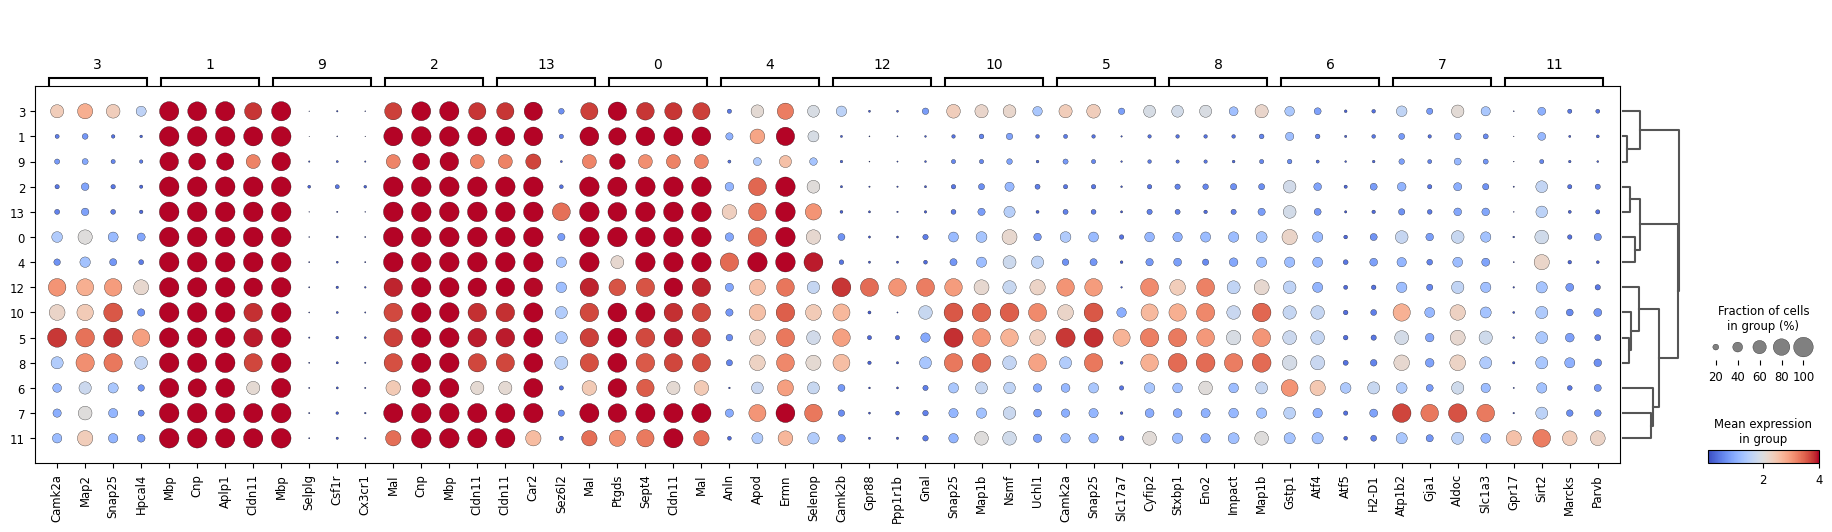

In [14]:
sc.pl.dotplot(
    adata_OL,
    var_names=cellclass_markers_top4,
    groupby="OL_louvain_1.0",
    color_map="coolwarm",
    vmax = 4,
    dendrogram=True
)

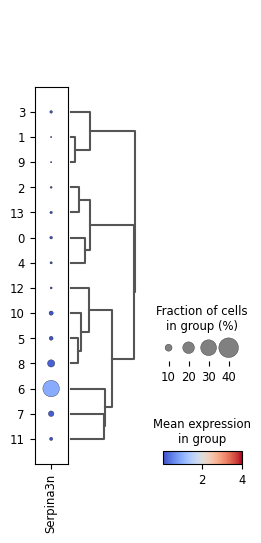

In [15]:
sc.pl.dotplot(
    adata_OL,
    var_names='Serpina3n',
    groupby="OL_louvain_1.0",
    color_map="coolwarm",
    vmax = 4,
    dendrogram=True
)

In [19]:
# Core OL lineage and disease/stress signatures (cleaned for missing genes)
OL_SIGNATURES = {
    # lineage states
    "OPC":        ["Pdgfra", "Cspg4", "Sox10", "Tnr"],
    "COP":        ["Dlk1", "Cspg5", "Tnr"],                # removed Bcan
    "NFOL":       ["Enpp6", "Tcf7l2", "Gpr17", "Klk6"],
    "MOL_myelin": ["Mbp", "Mog", "Mag", "Cnp", "Pllp"],   # removed Plp1

    # disease / stress axes
    "DOL_core":   ["Serpina3n", "C4b", "Trib3", "Atf4", "Hsph1", "Hspa1a", "Hspa1b", "Ddit3"],
    "ISR":        ["Atf4", "Trib3", "Ddit3", "Eif2ak3", "Atf5"],         # removed Asns
    "IFN":        ["Stat1", "Irf7", "Isg15", "Gbp2", "Cxcl10"],          # removed Oas1a
    "Astro_react":["Gfap", "Serpina3n"],                                # removed Vim, Lcn2
    "Immune_AP":  ["Cd40", "H2-Ab1", "H2-Aa", "Cd74", "Psmb8", "Psmb9"],  # intact
}

categories: 0, 1, 2, etc.
var_group_labels: OPC, COP, NFOL, etc.


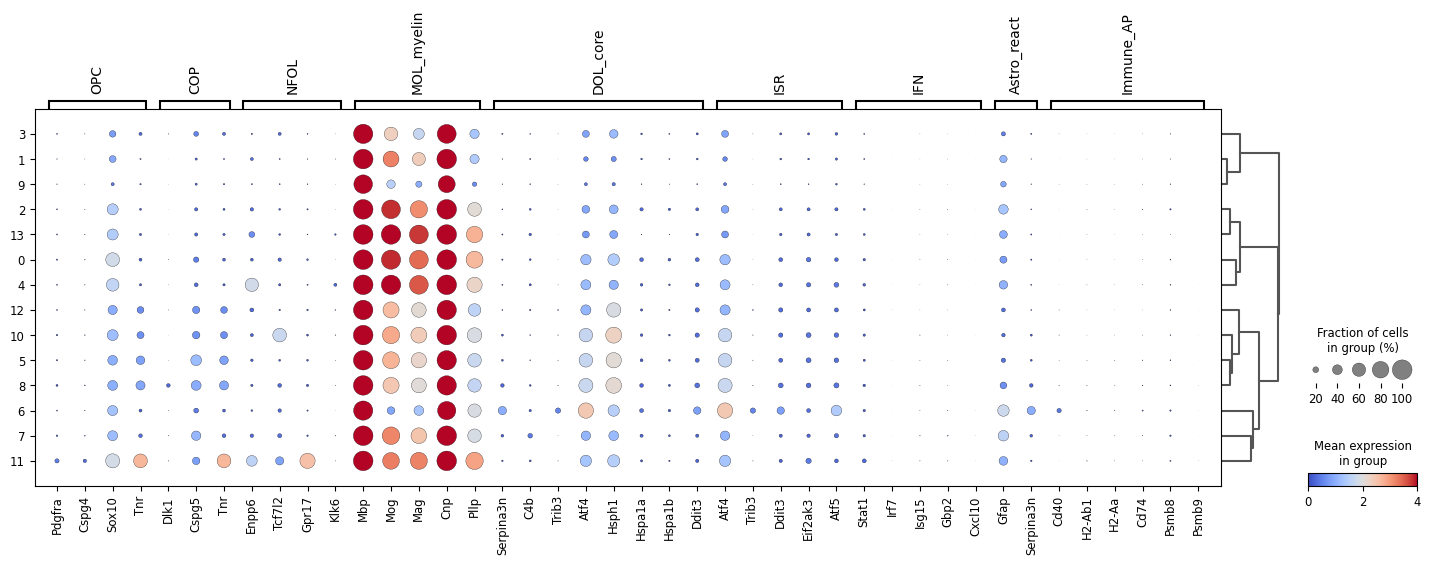

In [20]:
sc.pl.dotplot(
    adata_OL,
    var_names=OL_SIGNATURES,
    groupby="OL_louvain_1.0",
    color_map="coolwarm",
    vmax = 4,
    dendrogram=True
)

In [97]:

def label_by_max_score(ad, group_key="micro_leiden_1.0", panels=panels):
    scores = {}
    for name, genes in panels.items():
        gs = [g for g in genes if g in ad.var_names]
        if not gs: 
            continue
        sc.tl.score_genes(ad, gs, score_name=f"score_{name}", use_raw=False)
        scores[name] = f"score_{name}"
    labels = {}
    for cl in ad.obs[group_key].cat.categories:
        sub = ad[ad.obs[group_key] == cl]
        means = {name: float(sub.obs[scol].mean()) for name, scol in scores.items()}
        labels[cl] = max(means, key=means.get) if means else "Unknown"
    return labels

labels = label_by_max_score(adata_mic)

In [21]:
import scanpy as sc
import numpy as np

def score_signatures(
    adata,
    signatures: dict,
    prefix: str = "score_",
    ctrl_size: int = 50,
    n_bins: int = 25,
    use_raw: bool = False,
    verbose: bool = True,
):
    """
    Adds one column per signature to adata.obs: f'{prefix}{name}'.
    Auto-filters genes to those present in adata.var_names.
    """
    var_set = set(adata.var_names.astype(str))
    added = []
    for name, genes in signatures.items():
        genes = [g for g in genes if g in var_set]
        if len(genes) == 0:
            if verbose:
                print(f"⚠️  Skipping '{name}': no genes found in var_names.")
            continue
        if verbose:
            print(f"→ Scoring {name:12s} with {len(genes):2d} genes.")
        sc.tl.score_genes(
            adata,
            gene_list=genes,
            score_name=f"{prefix}{name}",
            ctrl_size=ctrl_size,
            n_bins=n_bins,
            use_raw=use_raw
        )
        added.append(f"{prefix}{name}")
    return added

In [22]:
# If you have an OL-only AnnData, use that; otherwise subset:
# adata_OL = adata[adata.obs['cell_class'].isin(['OPC','COP','NFOL','MOL','Oligodendrocytes'])].copy()

cols = score_signatures(adata_OL, OL_SIGNATURES, prefix="score_", ctrl_size=50, n_bins=25, use_raw=False)

# Optional: make a few composite scores (z-scored first)
def z(x):
    x = np.asarray(x, float)
    mu, sd = np.nanmean(x), np.nanstd(x)
    return (x - mu) / (sd if sd > 0 else 1)

obs = adata_OL.obs

# Maturation axis: (myelin) - (OPC)
obs["score_MaturationZ"] = z(obs.get("score_MOL_myelin", 0)) - z(obs.get("score_OPC", 0))

# Disease-tilt: DOL_core + ISR + IFN (averaged z)
obs["score_DiseaseZ"] = np.nanmean(
    np.c_[z(obs.get("score_DOL_core", 0)),
          z(obs.get("score_ISR", 0)),
          z(obs.get("score_IFN", 0))],
    axis=1
)

# Immune-tilt / antigen presentation
obs["score_ImmuneZ"] = z(obs.get("score_Immune_AP", 0))

# Astro contamination check (helpful if OL cluster picks up astro signal)
obs["score_AstroReactZ"] = z(obs.get("score_Astro_react", 0))

→ Scoring OPC          with  4 genes.
→ Scoring COP          with  3 genes.
→ Scoring NFOL         with  4 genes.
→ Scoring MOL_myelin   with  5 genes.
→ Scoring DOL_core     with  8 genes.
→ Scoring ISR          with  5 genes.
→ Scoring IFN          with  5 genes.
→ Scoring Astro_react  with  2 genes.
→ Scoring Immune_AP    with  6 genes.


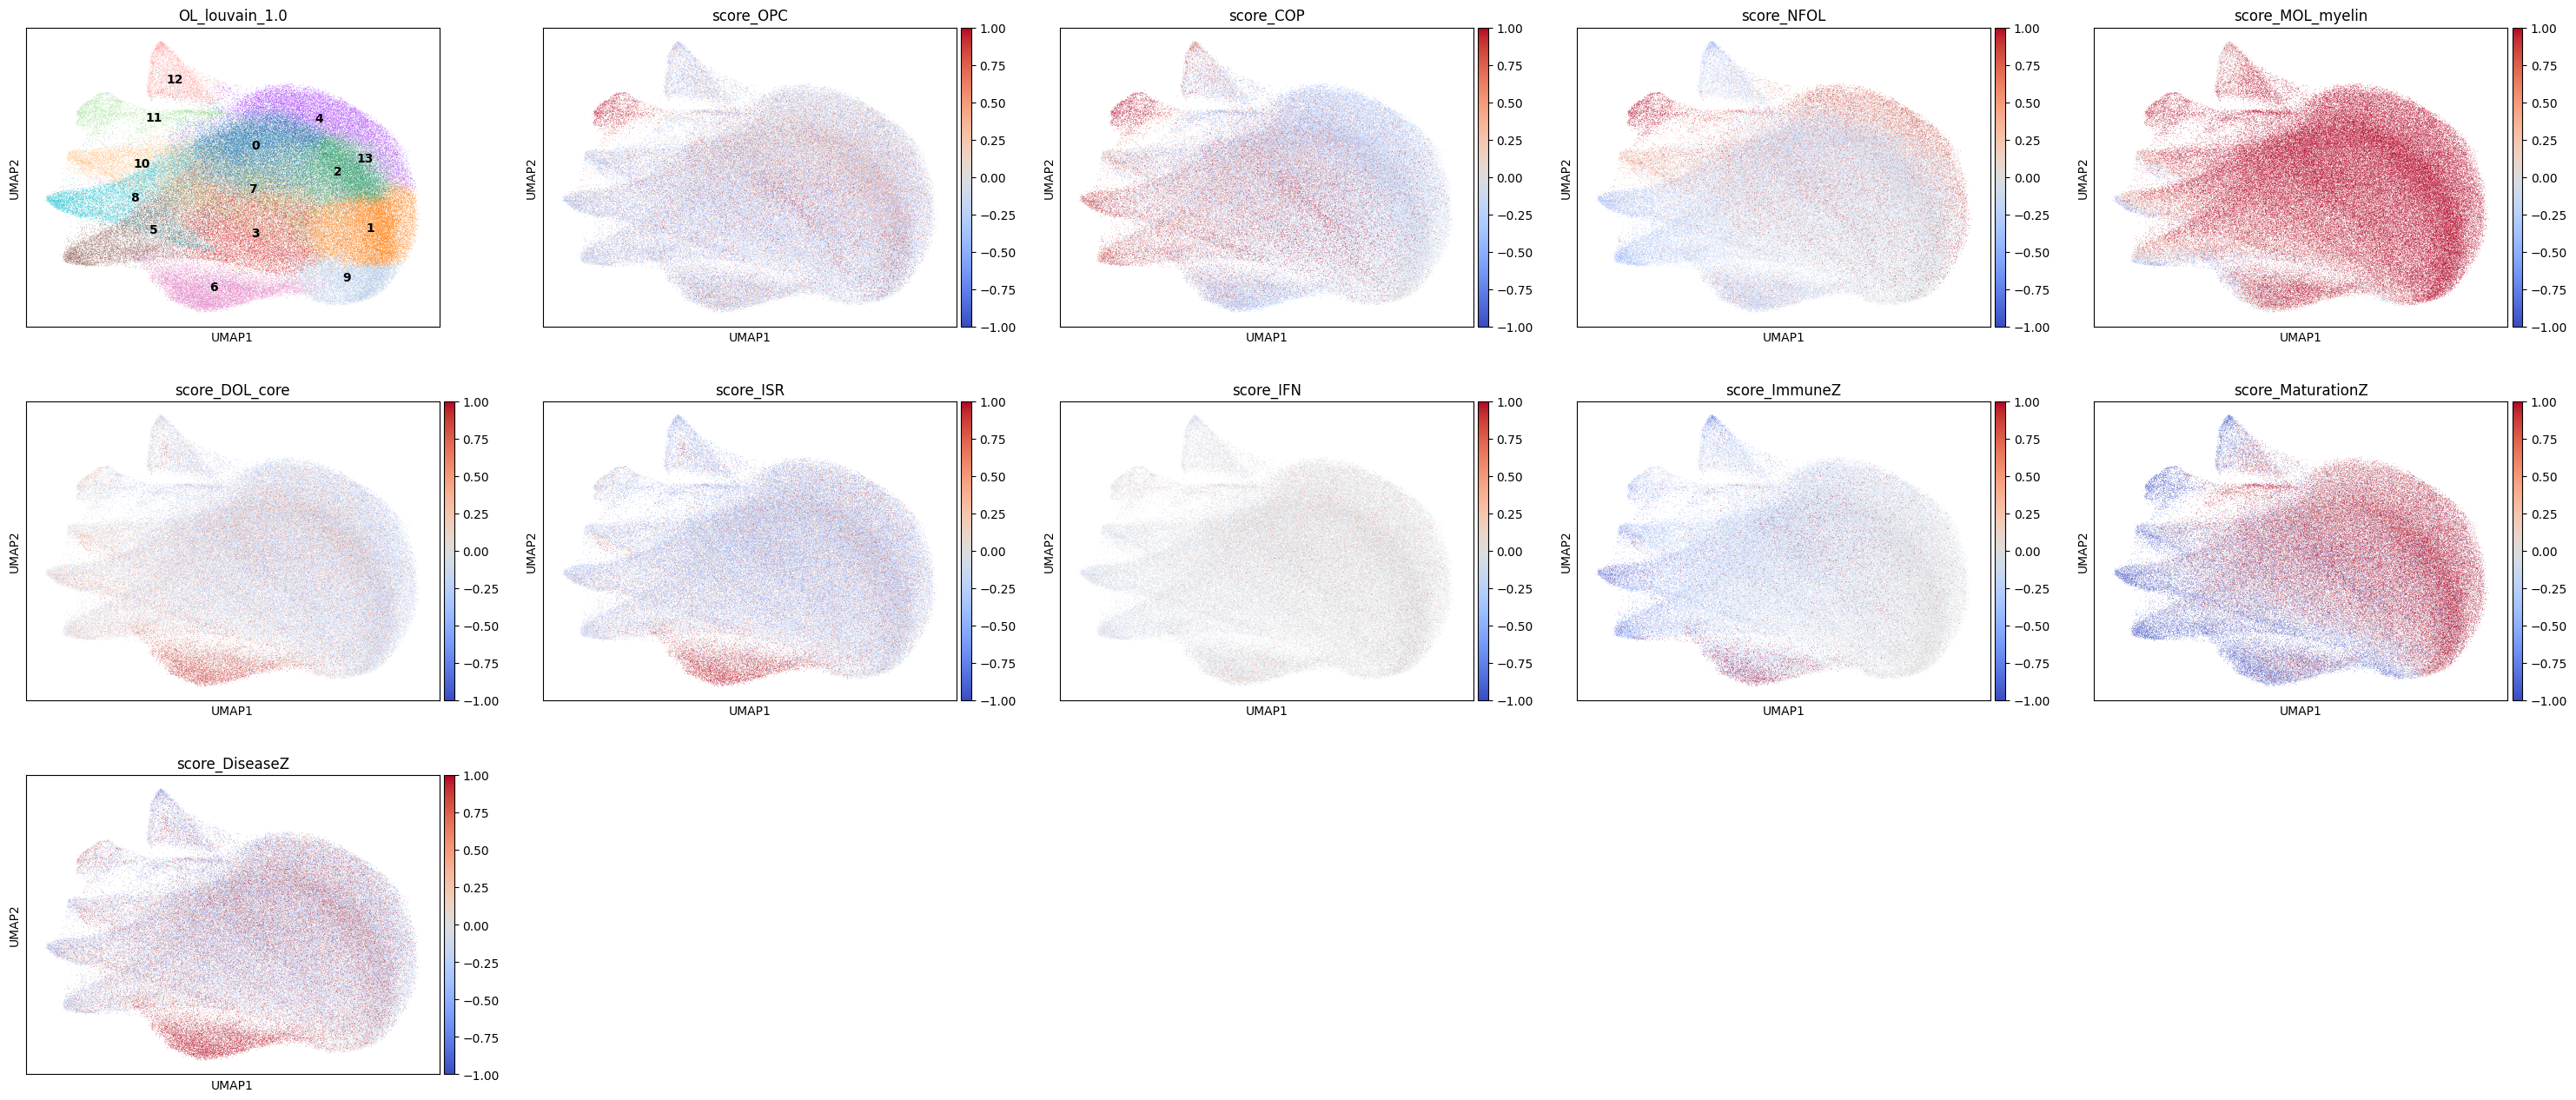

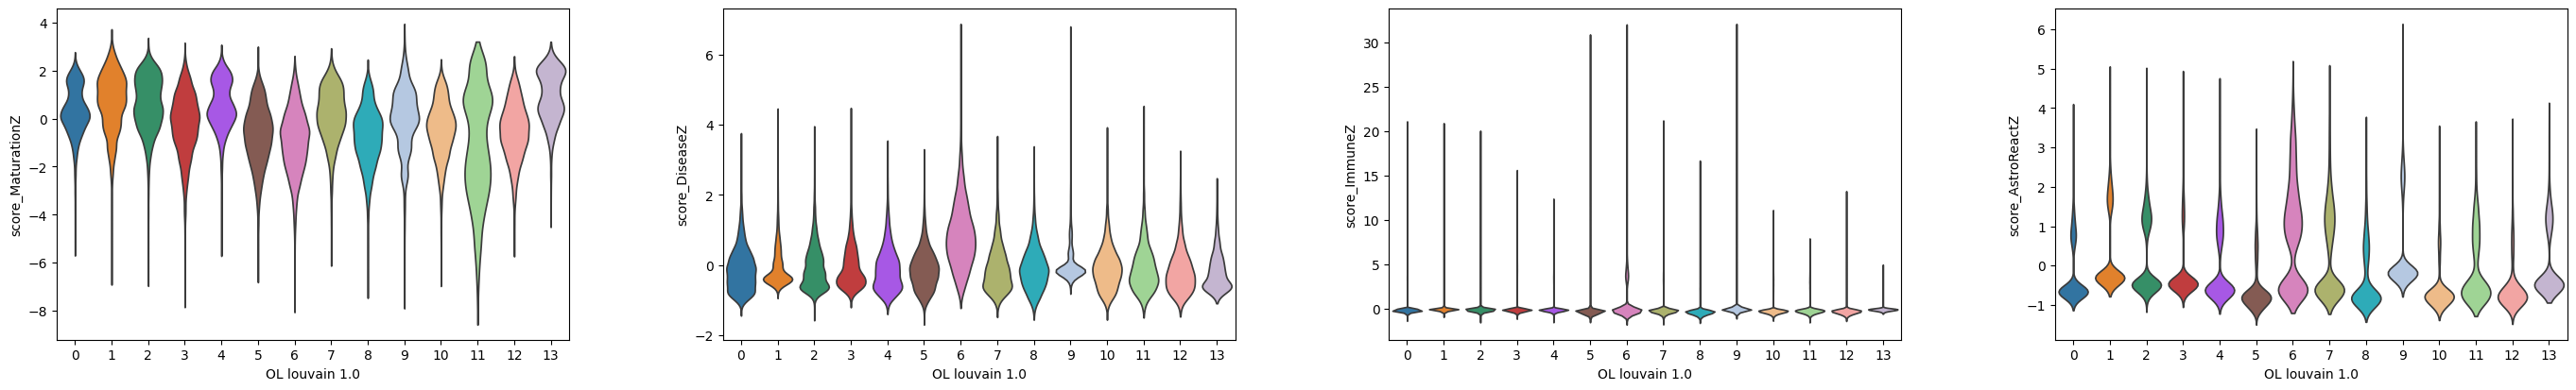

In [34]:
# UMAP overlays
sc.pl.umap(
    adata_OL,
    color=["OL_louvain_1.0","score_OPC","score_COP","score_NFOL","score_MOL_myelin",
           "score_DOL_core","score_ISR","score_IFN","score_ImmuneZ","score_MaturationZ","score_DiseaseZ"],
    vmin=-1, vmax=1, cmap="coolwarm", ncols=5, legend_loc='on data'
)

# Violin by cluster or region
sc.pl.violin(
    adata_OL,
    keys=["score_MaturationZ","score_DiseaseZ","score_ImmuneZ","score_AstroReactZ"],
    groupby="OL_louvain_1.0",
    stripplot=False, jitter=0.2
)

# Dotplot by condition/region (averages per group)
gene_modules = {
    "Lineage":      ["score_OPC","score_COP","score_NFOL","score_MOL_myelin"],
    "Disease_axes": ["score_DOL_core","score_ISR","score_IFN","score_ImmuneZ"]
}
# Scanpy dotplot expects genes; for module scores, use `var_names=...`-style:
# A simple workaround is to copy scores into .obsm and use sc.pl.matrixplot with 'values' arg,
# but easiest is violin/UMAP for module scores. For gene-level dotplots, use your original panels.

In [35]:
cluster = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12','13']
anno = ['Oligodendrocytes', 'Oligodendrocytes', 'Oligodendrocytes', 'Oligodendrocytes', 'Immature Oligodendrocytes', 'Oligodendrocytes', 'DA-Oligodendrocytes', 'Oligodendrocytes', 'Oligodendrocytes', 'Oligodendrocytes', 'Oligodendrocytes', 'Immature Oligodendrocytes', 'Oligodendrocytes','Oligodendrocytes']

In [37]:
adata_OL.obs['OL_ANNO'] = adata_OL.obs['OL_louvain_1.0'].map(dict(zip(cluster, anno)))

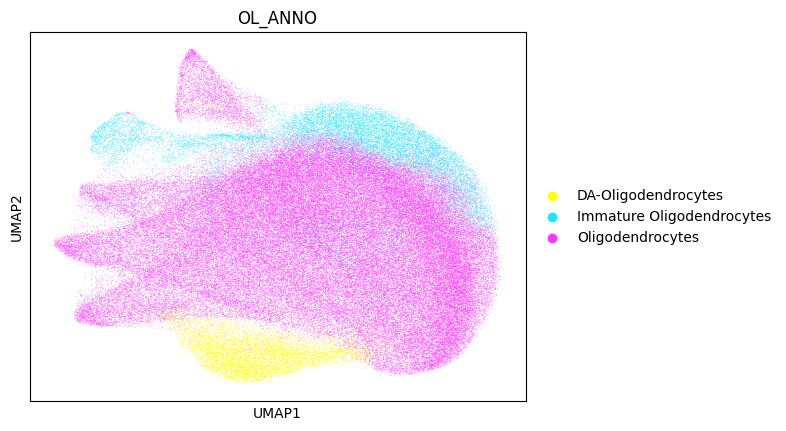

In [41]:
sc.pl.umap(adata_OL, color = 'OL_ANNO')

In [50]:
adata_OL.obs.sample_id.value_counts()

sample_id
RB4403    24064
RB4676    14552
RB4282    14494
RB4620    14391
RB4498    13560
RB4350    12717
RB4401    12587
RB4658    12484
RB4653    12139
RB4630    11772
RB4627    11184
RB4405    10945
Name: count, dtype: int64

Plotting OL_ANNO …


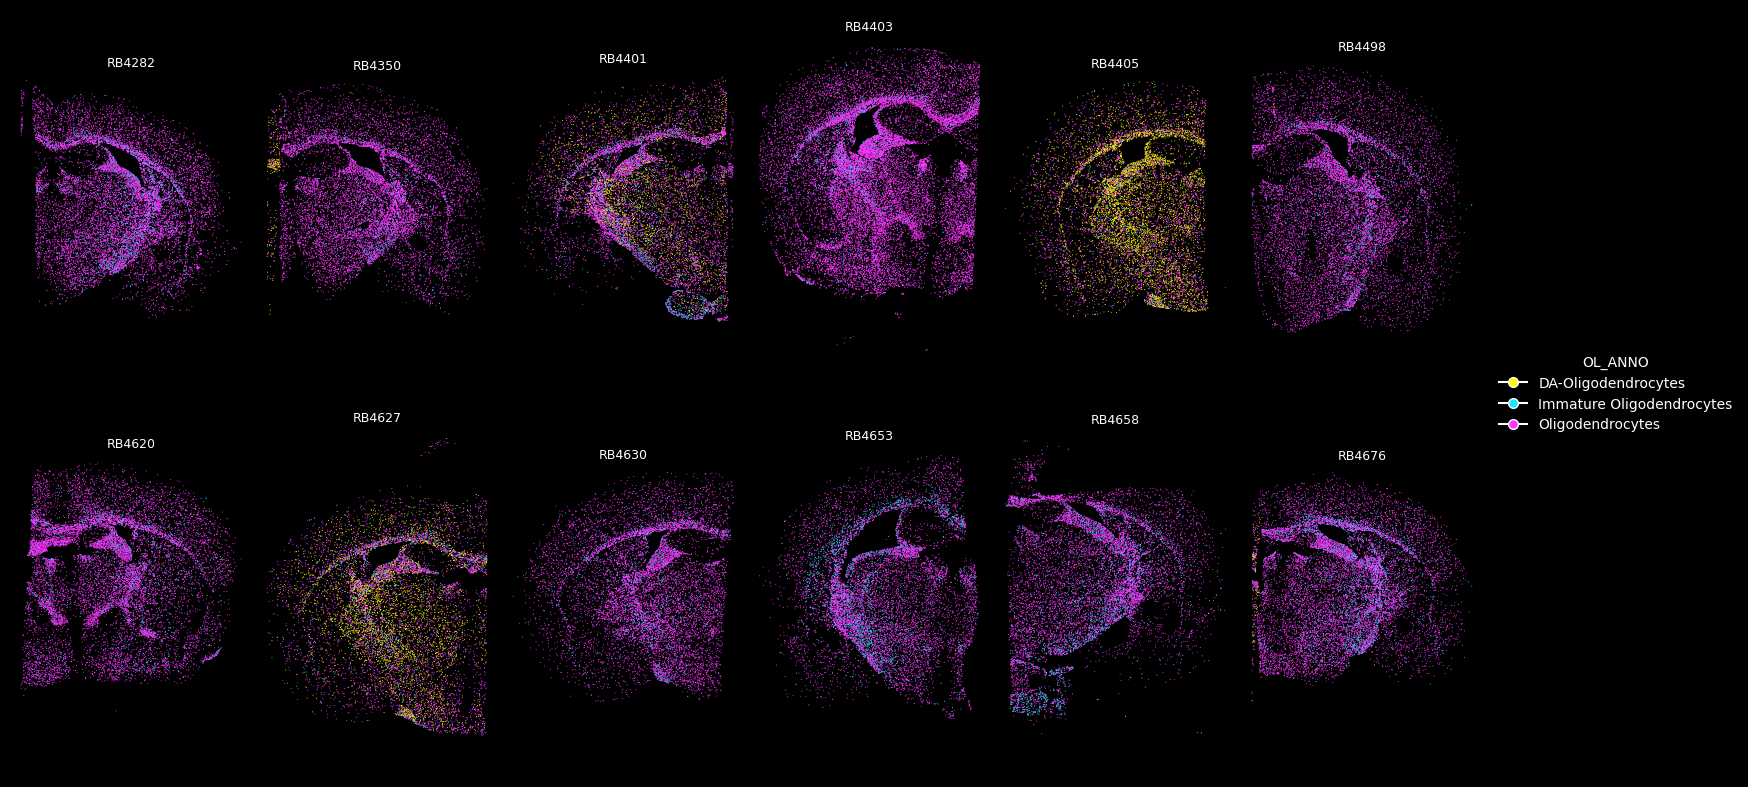

In [48]:
# --- make all axes dark background ---
plt.rcParams.update({
    "axes.facecolor": "black",     # axes background
    "figure.facecolor": "black",   # figure background
    "savefig.facecolor": "black",  # saved figure background
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "legend.edgecolor": "white",
    "legend.facecolor": "black",
    "legend.labelcolor": "white"
})

for domain in ['OL_ANNO']:
    if domain in adata_OL.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata_OL,
            color=domain,
            groupby="sample_id",
            spot_size=0.5,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")